# Word2Vec From Scratch (NumPy)

A from-scratch implementation of the Word2Vec skip-gram model, built using only NumPy — no deep learning frameworks. This notebook builds the model step by step: vocabulary, sliding-window pairs, embeddings, a full-softmax forward pass, manually derived gradients, negative sampling, and training on a real corpus (text8).

In [252]:
import string
import numpy as np
import matplotlib.pyplot as plt

## Loading the corpus (text8)

text8 is a cleaned, lowercase, punctuation-free slice of Wikipedia — commonly used as a lightweight corpus for word embedding exercises. Downloading and extracting it here.

In [253]:
import urllib.request
import zipfile

urllib.request.urlretrieve("http://mattmahoney.net/dc/text8.zip", "text8.zip")
with zipfile.ZipFile("text8.zip") as z:
    z.extractall()

with open("text8", "r") as f:
    raw_text = f.read()

Using only a slice of the full corpus (17M+ words) to keep training time manageable for a from-scratch, non-vectorized implementation.

In [277]:
text = raw_text.split()[:2000]  # first 20,000 words, adjust as needed

Sanity check — printing the slice back as readable text to confirm it loaded correctly and reads as coherent, meaningful content.

In [301]:
print(" ".join(text))

anarchism originated as a term of abuse first used against early working class radicals including the diggers of the english revolution and the sans culottes of the french revolution whilst the term is still used in a pejorative way to describe any act that used violent means to destroy the organization of society it has also been taken up as a positive label by self defined anarchists the word anarchism is derived from the greek without archons ruler chief king anarchism as a political philosophy is the belief that rulers are unnecessary and should be abolished although there are differing interpretations of what this means anarchism also refers to related social movements that advocate the elimination of authoritarian institutions particularly the state the word anarchy as most anarchists use it does not imply chaos nihilism or anomie but rather a harmonious anti authoritarian society in place of what are regarded as authoritarian political structures and coercive economic institutio

## Building the vocabulary

Taking the unique set of words from the text — this is the vocabulary the model will learn embeddings for.

In [279]:
utext = set(text)

Mapping every unique word to a numeric ID, since the model works with numbers, not raw text.

In [280]:
i = 0
word_to_id = {}
for word in utext:
  word_to_id[word] = i
  i = i + 1

print(word_to_id)

{'influential': 0, 'citium': 1, 'moniker': 2, 'france': 3, 'involved': 4, 'blamed': 5, 'on': 6, 'three': 7, 'co': 8, 'finest': 9, 'thick': 10, 'seen': 11, 'division': 12, 'economics': 13, 'price': 14, 'language': 15, 'had': 16, 'repudiated': 17, 'lacked': 18, 'all': 19, 'followers': 20, 'democratic': 21, 'anarchism': 22, 'included': 23, 'bad': 24, 'some': 25, 'spirit': 26, 'mutualists': 27, 'repeatedly': 28, 'most': 29, 'comes': 30, 'famous': 31, 'terrorism': 32, 'philosophy': 33, 'bertrand': 34, 'de': 35, 'amount': 36, 'must': 37, 'harmonious': 38, 'see': 39, 'do': 40, 'unite': 41, 'journal': 42, 'class': 43, 'considered': 44, 'can': 45, 'decreed': 46, 'late': 47, 'anomie': 48, 'organization': 49, 'concerning': 50, 'nature': 51, 'encouraged': 52, 'words': 53, 'eight': 54, 'leader': 55, 'simply': 56, 'stephen': 57, 'came': 58, 'jacque': 59, 'announced': 60, 'publishing': 61, 'holy': 62, 'radical': 63, 'utility': 64, 'products': 65, 'thing': 66, 'exchange': 67, 'russell': 68, 'related':

Building the reverse mapping (ID → word) directly from word_to_id, guaranteeing the two dictionaries always agree.

In [281]:
id_to_word = {v: k for k, v in word_to_id.items()}

print(id_to_word)

{0: 'influential', 1: 'citium', 2: 'moniker', 3: 'france', 4: 'involved', 5: 'blamed', 6: 'on', 7: 'three', 8: 'co', 9: 'finest', 10: 'thick', 11: 'seen', 12: 'division', 13: 'economics', 14: 'price', 15: 'language', 16: 'had', 17: 'repudiated', 18: 'lacked', 19: 'all', 20: 'followers', 21: 'democratic', 22: 'anarchism', 23: 'included', 24: 'bad', 25: 'some', 26: 'spirit', 27: 'mutualists', 28: 'repeatedly', 29: 'most', 30: 'comes', 31: 'famous', 32: 'terrorism', 33: 'philosophy', 34: 'bertrand', 35: 'de', 36: 'amount', 37: 'must', 38: 'harmonious', 39: 'see', 40: 'do', 41: 'unite', 42: 'journal', 43: 'class', 44: 'considered', 45: 'can', 46: 'decreed', 47: 'late', 48: 'anomie', 49: 'organization', 50: 'concerning', 51: 'nature', 52: 'encouraged', 53: 'words', 54: 'eight', 55: 'leader', 56: 'simply', 57: 'stephen', 58: 'came', 59: 'jacque', 60: 'announced', 61: 'publishing', 62: 'holy', 63: 'radical', 64: 'utility', 65: 'products', 66: 'thing', 67: 'exchange', 68: 'russell', 69: 'relat

Converting the full ordered text (including repeated words) into a list of IDs — needed for the sliding window, which depends on the real sequence of the text, not just the unique vocabulary.

In [282]:
id = []
for word in text:
  if word in word_to_id:
    id.append(word_to_id[word])
print(id)

[22, 171, 359, 342, 82, 378, 233, 366, 565, 515, 604, 234, 43, 707, 256, 259, 446, 378, 259, 166, 663, 483, 259, 275, 155, 378, 259, 284, 663, 573, 259, 82, 258, 158, 565, 112, 342, 190, 656, 559, 147, 655, 718, 664, 565, 653, 292, 559, 721, 259, 49, 378, 374, 303, 135, 270, 213, 681, 328, 359, 342, 591, 571, 649, 597, 297, 639, 259, 293, 22, 258, 440, 709, 259, 506, 96, 146, 321, 422, 222, 22, 359, 342, 622, 33, 258, 259, 126, 664, 447, 316, 177, 483, 220, 121, 623, 564, 344, 316, 673, 209, 378, 518, 694, 292, 22, 270, 124, 559, 69, 692, 324, 664, 676, 259, 388, 378, 638, 634, 161, 259, 363, 259, 293, 85, 359, 29, 639, 394, 303, 495, 662, 387, 226, 437, 706, 48, 217, 569, 342, 38, 238, 638, 374, 112, 247, 378, 518, 316, 246, 359, 638, 622, 563, 483, 449, 667, 634, 639, 676, 692, 609, 150, 279, 84, 542, 378, 738, 671, 187, 725, 483, 597, 432, 531, 22, 258, 29, 690, 297, 649, 518, 303, 258, 515, 639, 270, 326, 591, 409, 378, 518, 710, 498, 559, 121, 342, 103, 586, 374, 457, 544, 442, 15

## Generating training pairs (sliding window)

Walking through the text one word at a time, treating each word as a center word and pairing it with every word within `window_size` positions on either side (its context words). Edge cases (start/end of text) are handled with `max`/`min` bounds.

In [283]:
pairs = []
window_size = 2
for i in range(len(id)):
  for j in range(max(0, i - window_size), min(len(id), i + window_size + 1)):
    if j != i:
      pairs.append((id[i], id[j]))
print(pairs)

[(22, 171), (22, 359), (171, 22), (171, 359), (171, 342), (359, 22), (359, 171), (359, 342), (359, 82), (342, 171), (342, 359), (342, 82), (342, 378), (82, 359), (82, 342), (82, 378), (82, 233), (378, 342), (378, 82), (378, 233), (378, 366), (233, 82), (233, 378), (233, 366), (233, 565), (366, 378), (366, 233), (366, 565), (366, 515), (565, 233), (565, 366), (565, 515), (565, 604), (515, 366), (515, 565), (515, 604), (515, 234), (604, 565), (604, 515), (604, 234), (604, 43), (234, 515), (234, 604), (234, 43), (234, 707), (43, 604), (43, 234), (43, 707), (43, 256), (707, 234), (707, 43), (707, 256), (707, 259), (256, 43), (256, 707), (256, 259), (256, 446), (259, 707), (259, 256), (259, 446), (259, 378), (446, 256), (446, 259), (446, 378), (446, 259), (378, 259), (378, 446), (378, 259), (378, 166), (259, 446), (259, 378), (259, 166), (259, 663), (166, 378), (166, 259), (166, 663), (166, 483), (663, 259), (663, 166), (663, 483), (663, 259), (483, 166), (483, 663), (483, 259), (483, 275),

## Initializing the embeddings

Every word gets two separate vectors: one used when it's the center word, one used when it's a context word. Both start as small random values and get refined during training.

In [284]:
center_embeddings = np.random.randn(len(word_to_id), 10)
context_embeddings = np.random.randn(len(word_to_id), 10)

print(center_embeddings.shape)
print(context_embeddings.shape)

(741, 10)
(741, 10)


Saving a copy of the randomly initialized embeddings before any training happens — this becomes the 'before' snapshot for verifying later that training actually changed something meaningful.

In [285]:
initial_embeddings = center_embeddings.copy()

##Forward pass (single pair, full softmax)

For one (center, context) pair: compute a raw closeness score (dot product) between the center word and every word in the vocabulary, then turn those scores into probabilities using softmax. actual_prob is the probability the model currently assigns to the real context word.

In [300]:
center_id = 2
context_id = 5

center_vector = center_embeddings[center_id]

scores = center_vector @ context_embeddings.T

exp_scores = np.exp(scores - max(scores))

norm_scores = exp_scores / np.sum(exp_scores)

actual_prob = norm_scores[context_id]

print("Actual Probability:", actual_prob)

print("Sum of Normalized Scores:", np.sum(norm_scores))

Actual Probability: 0.0003305671022573917
Sum of Normalized Scores: 0.9999999999999999


##Loss (single pair)

Cross-entropy loss: the negative log of the probability assigned to the real answer. Low probability for the right answer → high loss; high probability → low loss.

In [287]:
loss = -np.log(actual_prob)

print(loss)

2.76218249928596


Sanity check — comparing the loss for a bad guess (this pair's low probability) against a hypothetical good guess (probability 0.9), to see the 'punish bad guesses more' behavior in real numbers.

In [288]:
good_prob = 0.9
good_loss = -np.log(good_prob)
print(good_loss)

0.10536051565782628


##Gradients (single pair)

For softmax + cross-entropy, the gradient with respect to the raw scores simplifies to: predicted probabilities minus the one-hot real answer (i.e., subtract 1 at the position of the true context word).

In [289]:
gradient_scores = norm_scores.copy()
gradient_scores[context_id] -= 1

print(gradient_scores.shape)

(741,)


Gradient for the center vector: how much each part of the center word's vector should change, based on its relationship (dot product) with the context embeddings.

In [290]:
center_gradients = np.dot(gradient_scores, context_embeddings)

print(center_gradients.shape)

(10,)


Gradient for the context embeddings: how much each word's context vector should change, based on its gradient score and the center vector — the dot product's 'other side'.

In [291]:
context_gradients = gradient_scores[:, np.newaxis] * center_vector

print(context_gradients.shape)

(741, 10)


Learning rate — controls how big each nudge is.

In [292]:
learning_rate = 0.1

Computing the updated center vector by stepping a small amount in the direction that reduces the loss.

In [293]:
new_center_vector = center_vector - learning_rate * center_gradients

Applying the update to the center embeddings matrix.

In [294]:
center_embeddings[center_id] = new_center_vector

Computing the updated context embeddings the same way.

In [295]:
new_context_embeddings = context_embeddings - learning_rate * context_gradients

Applying the update to the context embeddings matrix. This completes one full training step (forward pass → loss → gradients → update) for a single pair.

In [296]:
context_embeddings = new_context_embeddings

##Full training loop setup (with negative sampling)

Switching from full-vocabulary softmax to negative sampling for efficiency at real-corpus scale: instead of scoring against every vocabulary word, each pair is scored against the real context word plus a handful of randomly sampled 'negative' words, using a sigmoid instead of softmax.

In [297]:
epochs = 10
loss_history =[]
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

##Training loop

Looping over every (center, context) pair for several epochs. Each pair: sample negative words, compute sigmoid scores for the real pair and the negatives, compute loss, compute gradients, and update both embedding matrices in place. Total loss per epoch is tracked for plotting.

In [298]:
for epoch in range(epochs):
  total_loss = 0

  for center_id, context_id in pairs:

    center_vector = center_embeddings[center_id]

    negative_ids = np.random.choice(
        [i for i in range(len(word_to_id)) if i != context_id],
        5, replace=False
    )

    pos_score = sigmoid(np.dot(center_vector, context_embeddings[context_id]))
    neg_scores = sigmoid(np.dot(context_embeddings[negative_ids], center_vector))

    loss = -np.log(pos_score) - np.sum(np.log(1 - neg_scores))
    total_loss += loss

    grad_pos = pos_score - 1
    grad_neg = neg_scores

    center_gradients = grad_pos * context_embeddings[context_id] + np.dot(grad_neg, context_embeddings[negative_ids])

    context_embeddings[context_id] -= learning_rate * grad_pos * center_vector
    context_embeddings[negative_ids] -= learning_rate * grad_neg[:, np.newaxis] * center_vector
    center_embeddings[center_id] -= learning_rate * center_gradients

  loss_history.append(total_loss)

print(loss_history)

[np.float64(44201.042550103964), np.float64(23410.31560119369), np.float64(17882.326702918646), np.float64(16180.253258228522), np.float64(15163.411925567923), np.float64(14486.299997198503), np.float64(13891.144858603631), np.float64(13324.728218860835), np.float64(12910.242423966476), np.float64(12566.336598792457)]


##Loss curve

Plotting total loss per epoch — a smooth downward trend confirms the training pipeline (forward pass, loss, gradients, updates) is implemented correctly.

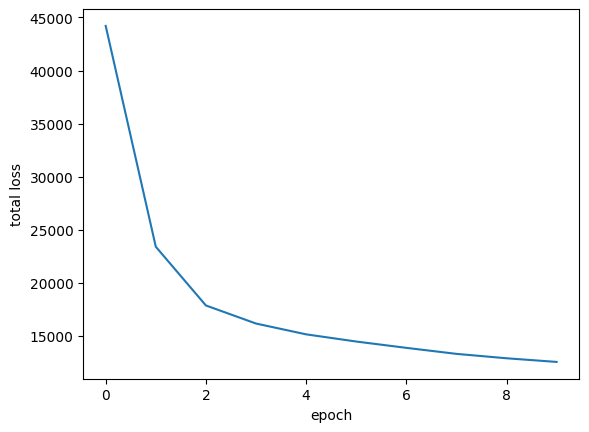

In [299]:
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("total loss")
plt.show()

##Verifying the embeddings learned something real

Checking which real-world word pairs of interest are actually present in this text slice's vocabulary, before testing their similarity.

In [302]:
for w in ["anarchism", "anarchist", "state", "government", "communism", "kropotkin"]:
    print(w, w in word_to_id)

anarchism True
anarchist True
state True
government False
communism True
kropotkin True


Comparing cosine similarity between related word pairs before training (using the saved initial_embeddings) and after training (using the trained center_embeddings). A meaningful increase in similarity for genuinely related words is direct evidence that training moved the embeddings in a meaningful way.

In [303]:
def check_similarity(word1, word2, embeddings):
    v1 = embeddings[word_to_id[word1]]
    v2 = embeddings[word_to_id[word2]]
    dot = np.dot(v1, v2)
    sim = dot / (np.linalg.norm(v1) * np.linalg.norm(v2))
    return sim

pairs_to_check = [("anarchism", "anarchist"), ("anarchism", "communism"), ("state", "kropotkin")]

for w1, w2 in pairs_to_check:
    before = check_similarity(w1, w2, initial_embeddings)
    after = check_similarity(w1, w2, center_embeddings)
    print(f"{w1} / {w2} — before: {before:.4f}, after: {after:.4f}")

anarchism / anarchist — before: -0.1573, after: 0.3761
anarchism / communism — before: -0.4030, after: 0.3639
state / kropotkin — before: 0.1448, after: 0.5923
